<a href="https://colab.research.google.com/github/sudipto291088/DATA_201_SPRING_2026_SUDIPTO/blob/main/Week_3_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA 201 -- Week 3 Assignment  
Visualization + Linear Regression (R → Python Bridge)  
Submission: Jupyter Notebook (.ipynb)\ Dataset: housing.csv\ Focus: Interpretation > Syntax             






Part I -- Visualization (40 pts)  



A. Scatterplots and Aesthetics  
Create a scatterplot of size vs price.  

Label axes clearly.   
Add a meaningful title.   
Recreate the plot using color = neighborhood (use seaborn).   

Use transparency (alpha) to reduce overplotting.   







Short Answer (3--4 sentences)  
What does seaborn automatically handle that matplotlib does not?  
Why is transparency useful here?  

In [ ]:
## Importing the libraries and the Dataset



import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("housing.csv")

df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


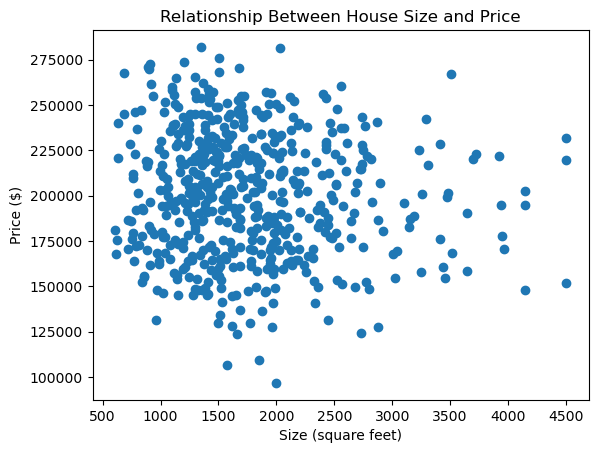

In [ ]:
## Basic Scatterplot

plt.scatter(df["size"], df["price"])

plt.xlabel("Size (square feet)")
plt.ylabel("Price ($)")
plt.title("Relationship Between House Size and Price")

plt.show()

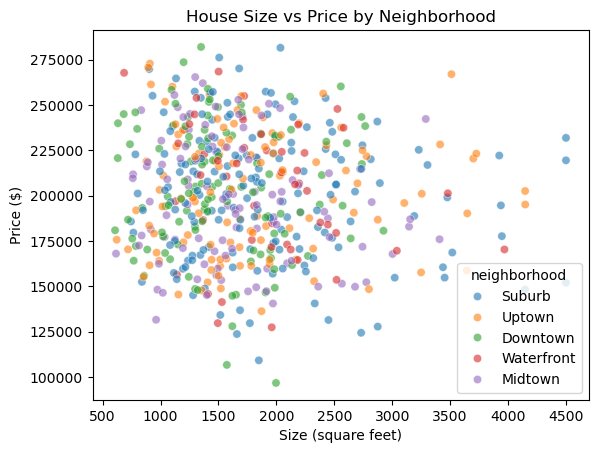

In [ ]:
## Scatterplot using Seaborn with Neighborhood Color

sns.scatterplot(
    data=df,
    x="size",
    y="price",
    hue="neighborhood",
    alpha=0.6
)

plt.xlabel("Size (square feet)")
plt.ylabel("Price ($)")
plt.title("House Size vs Price by Neighborhood")

plt.show()


## Short Answer (3--4 sentences)

## What does seaborn automatically handle that matplotlib does not? Why is transparency useful here?

Seaborn handles statistical visualization  like grouping or color mapping plus default styling better.
In Matplotlib that would require additional steps.
Seaborn directly works with pandas Dataframe plus helps in revealing patterns ie 'transparency' that would otherwise be hidden.

B. Small Multiples (Faceting)  
Create small multiples of size vs price, separated by bedrooms.  

Keep scales consistent.  
Add a clear overall title.  
Question<br>
Does the relationship between size and price look similar across bedroom counts?

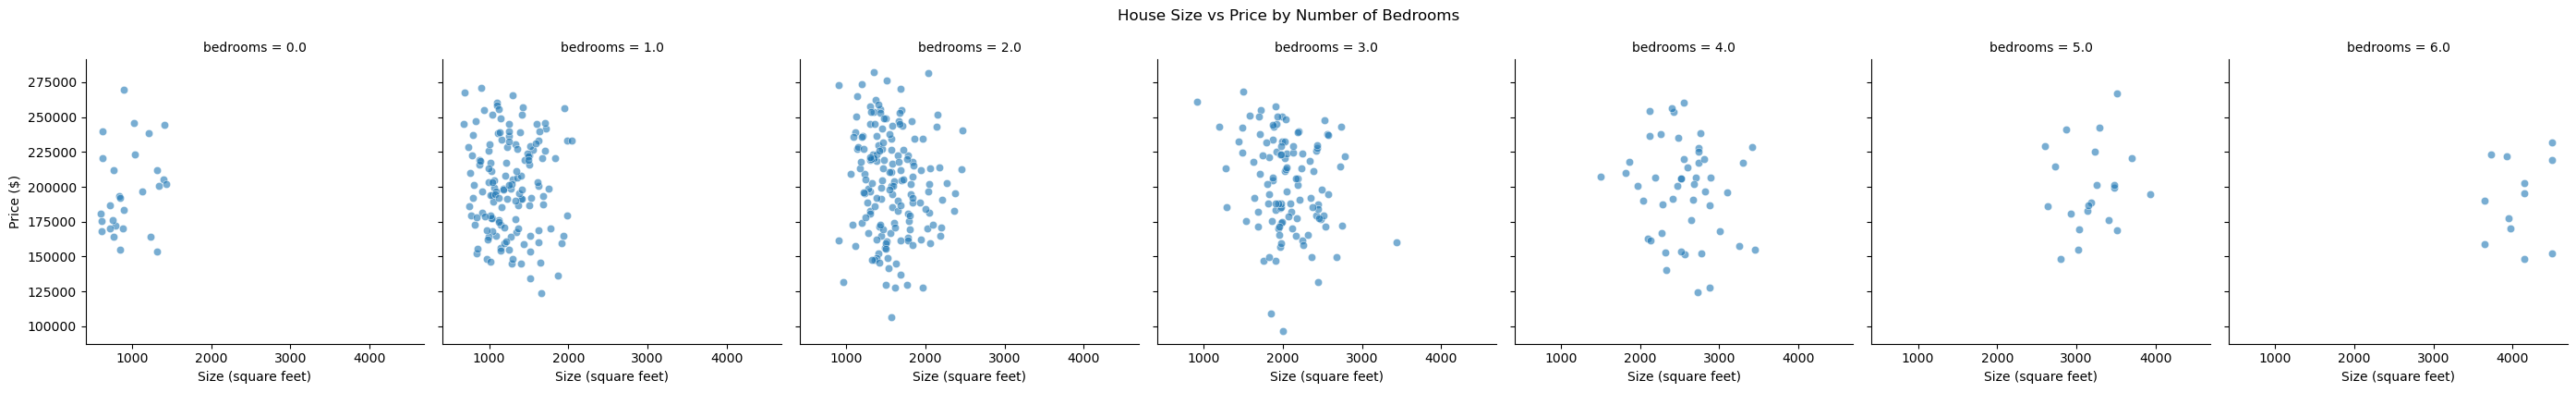

In [ ]:
g = sns.FacetGrid(df, col="bedrooms", height=4, sharex=True, sharey=True)

g.map_dataframe(
    sns.scatterplot,
    x="size",
    y="price",
    alpha=0.6
)

g.set_axis_labels("Size (square feet)", "Price ($)")
g.fig.suptitle("House Size vs Price by Number of Bedrooms", y=1.05)

plt.show()

## Does the relationship between size and price look similar across bedroom counts?

The relationship between size and price generally looks positive across the bedroom counts. The larger houses usually cost more.
Also, houses with more bedrooms often appear at bigger sizes and higher prize ranges.

C. Distribution and Categorical Plots  
Create a histogram of price.     
Create a density plot of price.  
Create a boxplot of price by neighborhood.   
Interpretation (short paragraph)   
Do neighborhoods differ systematically in price?  
What visual evidence supports your claim?   

In [ ]:
df["price"].nunique()

1

In [ ]:
df.columns

Index(['listing_id', 'price', 'size', 'bedrooms', 'neighborhood', 'type'], dtype='object')

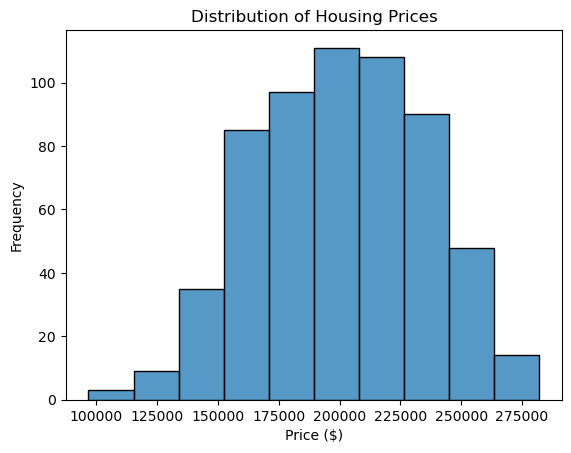

In [ ]:
## Histogram of Price


sns.histplot(df["price"], bins=10)

plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Housing Prices")

plt.show()

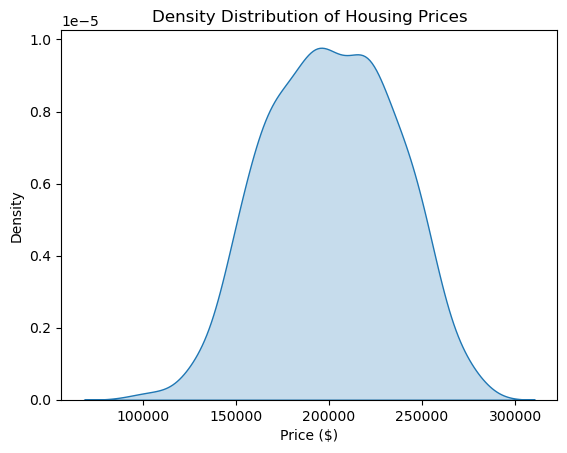

In [ ]:
## Density Plot of Price

sns.kdeplot(df["price"], fill=True)

plt.xlabel("Price ($)")
plt.title("Density Distribution of Housing Prices")

plt.show()

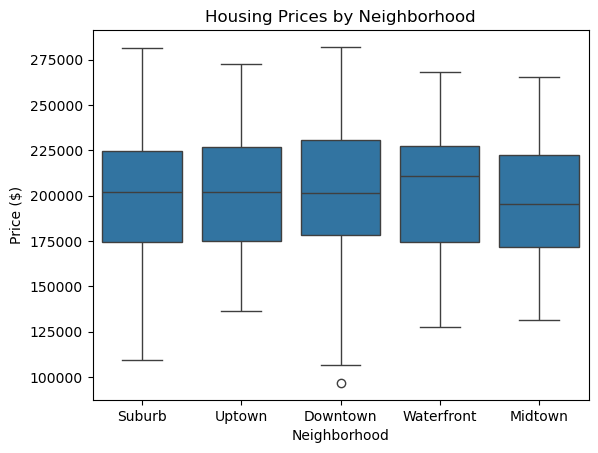

In [ ]:
## Boxplot of Price by Neighbourhood


sns.boxplot(
    data=df,
    x="neighborhood",
    y="price"
)

plt.xlabel("Neighborhood")
plt.ylabel("Price ($)")
plt.title("Housing Prices by Neighborhood")

plt.show()

The Neighborhoods do differ in price as per the Boxplot described above. Some of the neighbourhood have higher median prices than others.
The spread and range also vary across the neighborhoods. Everything is clear from the boxplot above.


Part II -- Linear Regression for Inference (30 pts)  
A. Multiple Regression (R → Python)  
In R, the model would be:  

lm(price ~ size + bedrooms + neighborhood, data = df)  
In Python:  

Fit the equivalent model using statsmodels.  
Report:  
Coefficient estimates  
Standard errors  
R²  


In [ ]:
import statsmodels.formula.api as smf

In [ ]:
## Fitting the multiple regression model


model = smf.ols(
    "price ~ size + bedrooms + C(neighborhood)",
    data=df
).fit()





print(model.summary())

In [ ]:
##Coefficients

model.params

Intercept                        211150.598641
C(neighborhood)[T.Midtown]        -4236.187661
C(neighborhood)[T.Suburb]          -562.702866
C(neighborhood)[T.Uptown]          1311.102496
C(neighborhood)[T.Waterfront]      3001.335508
size                                -10.934475
bedrooms                           4372.264288
dtype: float64

In [ ]:
##Standard Error

model.bse

Intercept                        4925.106171
C(neighborhood)[T.Midtown]       4809.528892
C(neighborhood)[T.Suburb]        4369.989429
C(neighborhood)[T.Uptown]        4727.959454
C(neighborhood)[T.Waterfront]    5984.299172
size                                4.209675
bedrooms                         2262.445453
dtype: float64

In [ ]:
## R2


model.rsquared

0.016666751060416374

B. Interpretation  
Answer clearly:  

Interpret the coefficient on size, explicitly stating what is being held constant.  
Is size statistically significant? How do you know?  
What does R² tell us in this context?  

The no. of bedrooms and neighborhood was hold constant.
It actually estimated how much the price of the house increaded when the size increased by 1 sq.foot.
+ve coefficient usually indicates larger houses tend to have higher prices.

Statistical significance was determined by the p-value associated with the size coefficient in the regression output.  
when the p-value<0.0.5 we consider the variable to be statistically significant.  

R2 represents the proportion of variation in house prices explained by the predictors in the model (size, bedrooms, and neighborhood).  
Higher R2 means the model did a better job in laying out the differences in house prices across observations.

Part III -- Prediction Workflow (20 pts)  
Now switch goals: Prediction instead of explanation  

Split the data into training and test sets.  
Fit linear regression using scikit-learn.  
Compute:  
RMSE (on test set)  
R² (on test set)  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

In [ ]:
df = df.dropna()

In [ ]:
X = df[["size", "bedrooms", "neighborhood"]]
X = pd.get_dummies(X, columns=["neighborhood"], drop_first=True)

y = df["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
## Fitting Linear regression Model


model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("RMSE:", rmse)

RMSE: 37867.66913742972


C:\Users\bhadr\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
r2 = r2_score(y_test, y_pred)
print("Test R²:", r2)

Test R²: -0.05028057712127332


Short Answer  
Why does scikit-learn not report p-values?  
Which workflow would you use for:  
Explanation?  
Prediction?  
Why are these different goals?  

Scikit is ideal mostly for machine learning and prediction goes along with it. Not exactly statistical in nature. The calculations of pvalue entails
statistical knowledge which are actually not a part of scikit-learn's component.

for workflow it shall be statsmodel since it provide the statistical outputs such as coefficients and standard errors.   

for prediction it shall be scikit learn since it provides the necessary tools for training and testing.

Explanation aims to understand the relationship between variables and the significance of predictors, while prediction focuses on accurately forecasting outcomes on new data.
Since the objectives are different, the tools and evaluation methods used for each workflow are also different.

Part IV -- Integrated Thinking (10 pts)  
Create one polished figure that:  

Shows size vs price  
Colors by neighborhood  
Includes a regression line  
Has professional formatting  
Then write 4--5 sentences:  

Does the regression model match what you visually observed?  
Did the visualization help you anticipate the model results?  

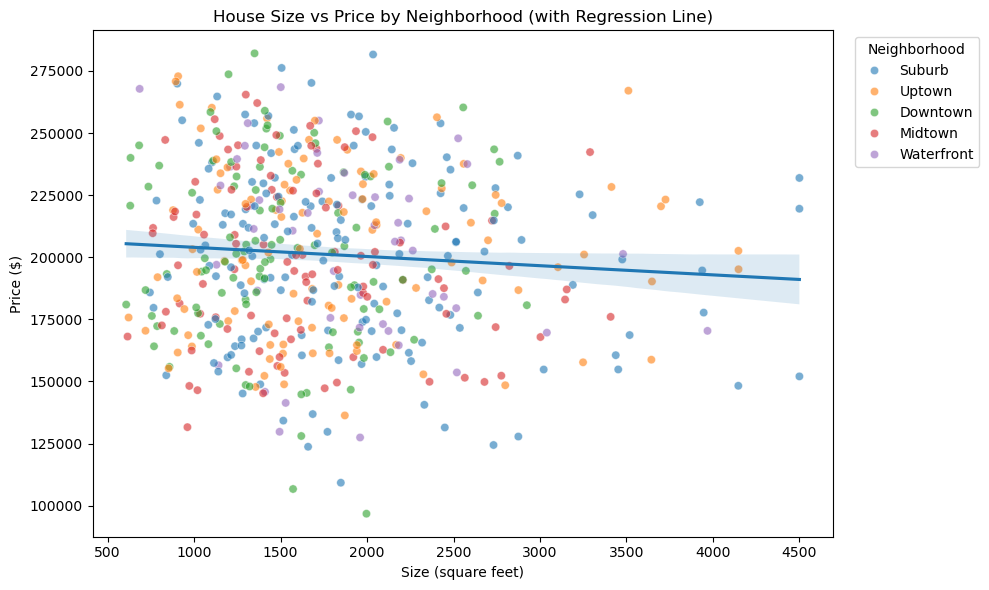

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="size",
    y="price",
    hue="neighborhood",
    alpha=0.6
)

# overall regression line (ignores neighborhood categories, like a single global trend line)
sns.regplot(
    data=df,
    x="size",
    y="price",
    scatter=False
)

plt.xlabel("Size (square feet)")
plt.ylabel("Price ($)")
plt.title("House Size vs Price by Neighborhood (with Regression Line)")
plt.legend(title="Neighborhood", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

As we notice the model ie the regression model above generally matches with the result of the scatterplot display.

- as house size increases the price tends to increase as well.

We also notice the regression line cleanly summarizes the overall upward trend which is visible across the points. The color grouping is also on point.

Indeed, the visualization helped us understand and anticipate the model result since it brings out clearly the positive relationship between size and the price.  